# Fundamental Frequency (F0 / Pitch)

## Simple YIN Algorithm


In [1]:
def simple_yin(x, sr, fmin=65, fmax=1000):
# Convert frequency bounds to period bounds
    max_tau = int(sr / fmin)
    min_tau = int(sr / fmax)

    diffs = []
    for tau in range(min_tau, max_tau + 1):
        d = np.sum((x[:-tau] - x[tau:])**2)
        diffs.append(d)
    diffs = np.array(diffs)

    # Find first strong minimum
    taus = np.arange(min_tau, max_tau + 1)
    best_tau = taus[np.argmin(diffs)]
    f0 = sr / best_tau
    return f0

In [6]:
import numpy as np

In [5]:
sr = 16000
t = np.linspace(0, 2, sr * 2)
x = np.sin(2 * np.pi * 150 * t)
print(simple_yin(x, sr)) 

75.11737089201878


In [1]:
from numpy import linalg
import matplotlib.pyplot as plt
from matplotlib import animation

import librosa
import IPython.display as ipd
from tqdm import tqdm

In [3]:
audio, sr = librosa.load("Jane.mp3", sr = 16000)

In [4]:
audio

array([ 4.4049362e-13, -6.6815551e-14, -1.5704102e-13, ...,
        7.4539097e-11,  1.8728485e-10, -8.3940944e-11], dtype=float32)

In [5]:
f0, voiced_flag, voiced_probs = librosa.pyin(audio, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C6'))

f0_voiced = f0[voiced_flag]
times = librosa.times_like(f0, sr=sr)

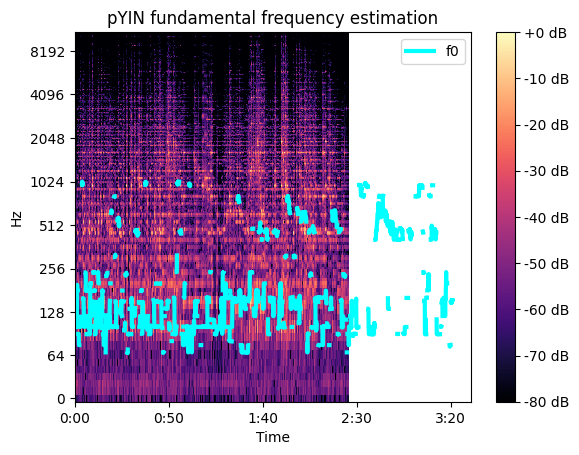

In [7]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)

fig, ax = plt.subplots()
img = librosa.display.specshow(D, x_axis='time', y_axis='log', ax=ax)
ax.set(title='pYIN fundamental frequency estimation')
fig.colorbar(img, ax=ax, format="%+2.f dB")
ax.plot(times, f0, label='f0', color='cyan', linewidth=3)
ax.legend(loc='upper right')

In [26]:
x, sr = librosa.load("Jane.mp3", sr=16000, mono=False)
x = x[0, :]

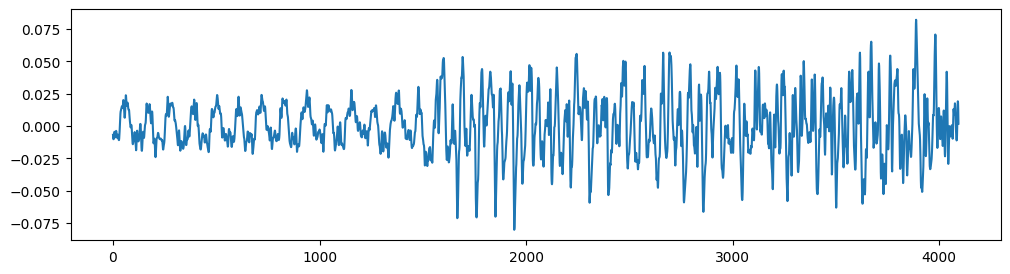

In [38]:
i0 = int(sr*31)
frame = 8191
win = frame//2
xf = x[i0:i0+frame]
plt.figure(figsize=(12, 3))
plt.plot(xf[0:win])

In [39]:
ipd.Audio(np.concatenate([xf]*10), rate=sr)

## Auto correlation

In [41]:
T = 60 # Period, in samples
f = sr/T # frequency
t = np.arange(sr*2)/sr # Two second tone
y = np.cos(2*np.pi*f*t)

ipd.Audio(y, rate=sr)


In [35]:
12*np.log2(f/440)

np.float64(-8.669592293653093)

### $r_w[k] = \sum_{n}^{w-1} x_f[n] x_f[n+k]$

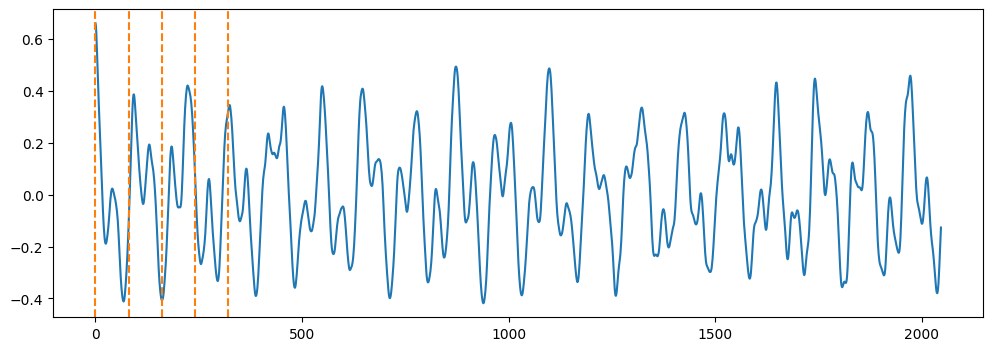

In [60]:
def simple_corr(xf):

    frame = xf.size
    win = frame//4

    r = np.zeros(win+1)
    for k in range(win+1):

        r[k] = np.sum(xf[0:win] * xf[k: k+win])
    return r

plt.figure(figsize=(12, 4))
plt.plot(simple_corr(xf))

for k in range(0, 400, 80):
    plt.axvline(k, linestyle='--', c='C1')

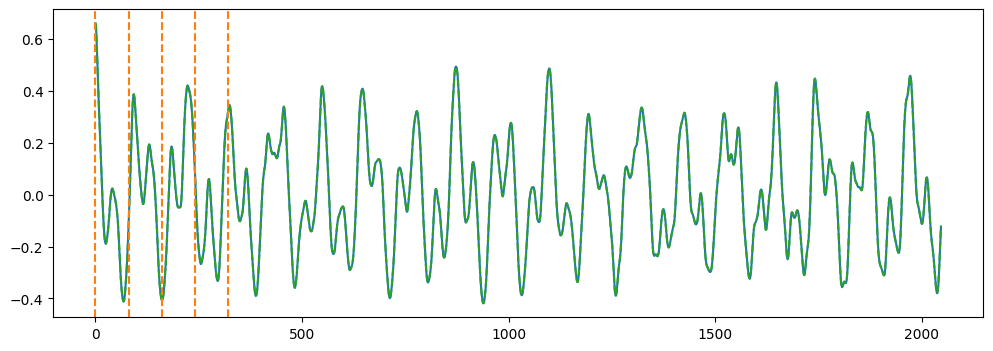

In [64]:
def autocorr(xf):
    win = xf.size//4
    a = np.fft.rfft(xf) # signal unperturb
    b= np.fft.rfft(xf[0:win], xf.size) # for zero padding
    r = np.fft.irfft(a*np.conj(b)) # filp - Convolution

    return r[0:win+1]

plt.figure(figsize=(12, 4))
plt.plot(simple_corr(xf), c= 'C0')
plt.plot(autocorr(xf), c = 'C2', linestyle='--')

for k in range(0, 400, 80):
    plt.axvline(k, linestyle='--', c='C1')